# Nestlé Distributed Order Management (DOM)
## Quantum vs Classical Optimization – Full Investigation Notebook

**Objective:** Recommend DC reassignments for focus orders that cannot be fully satisfied by their default distribution centre, maximising fulfilment value while balancing revenue, penalties, shipping cost, and capacity.

**This notebook covers:**
1. Business context & combinatorial nature of DOM
2. Data loading and focus-order selection
3. Classical baselines (Default, Greedy)
4. Mathematical formulation (QUBO aligned with business objective)
5. Quantum method theory (QAOA + Warm-Start + CVaR)
6. Exact classical solver on the same QUBO
7. Quantum runs and comparison
8. Plots, results tables, and interpretation


## 1. Business Context: Why DOM is a Combinatorial Optimisation Problem

At Nestlé, customer orders are normally fulfilled from a **default DC**. When inventory, throughput, labour or dock capacity is insufficient, planners must **divert** the order to an alternate DC.

Key trade-offs:
- **Fill rate / revenue** vs **shipping cost** vs **penalty for unmet demand**
- An order may be assigned to **at most one DC**
- Shared capacity (dock, picks, inventory) couples decisions across orders → the problem is **combinatorial**

Static rules and manual diversion are slow and leave money on the table. An optimisation model can systematically explore the assignment space.

**Why advanced / quantum methods?**  
For \(n\) focus orders and \(m\) candidate DCs the number of feasible one-hot assignments is \(m^n\). Even modest instances (\(n=15, m=5\)) exceed \(10^{10}\) combinations. Exact MILP scales poorly; heuristics can be myopic. Quantum / quantum-inspired algorithms (QAOA, quantum annealing) offer an alternative search paradigm that can exploit superposition over the assignment space.


## 2. Environment Setup & Imports

We use **Qiskit** for the quantum circuit (QAOA ansatz), **qiskit-optimization** for the QuadraticProgram / Ising conversion, and classical libraries for data handling and plotting.


In [1]:

import time, warnings
from typing import Dict, List, Tuple
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import StatevectorSampler
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import NumPyMinimumEigensolver
from scipy.optimize import minimize

np.random.seed(7)
print('Libraries loaded successfully.')


Libraries loaded successfully.


## 3. Configuration

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `MAX_FOCUS` | 3 | Number of high-priority focus orders (keeps problem tractable for exact enumeration & statevector simulation) |
| `DCS` | [5083, 5420, 5620] | Candidate distribution centres |
| `COF_LIFT` | 0.05 | Assumed fill-rate improvement when diverting (≥ 5 % rule from Nestlé POC) |
| `COVER_PENALTY` | \(2\times10^6\) | Strong one-hot cover penalty so infeasible states cannot beat feasible ones |
| `USE_CAPACITY` | False | Capacity soft-penalty switched off for the pure-business investigation |
| `QAOA_P` | 2 | QAOA depth (number of cost/mixer layers) |
| `CVAR_ALPHA` | 0.25 | Conditional Value-at-Risk tail fraction for robust optimisation |
| `N_RUNS` | 5 | Independent QAOA optimisations with different seeds |


In [2]:

MAX_FOCUS = 3
DCS = [5083, 5420, 5620]
COF_LIFT = 0.05
COVER_PENALTY = 2.0e6
USE_CAPACITY = False
CAP_ALPHA = 0.0
QAOA_P = 2
QAOA_MAXITER = 60
CVAR_ALPHA = 0.25
N_RUNS = 5

ORDER_CSV = '/home/workdir/attachments/Output_order_level_data.csv'
SHIP_CSV  = '/home/workdir/attachments/input_shipping_cost_data.csv'

print(f'Config: {MAX_FOCUS} orders × {len(DCS)} DCs = {MAX_FOCUS*len(DCS)} binary variables')
print(f'COVER_PENALTY={COVER_PENALTY:.0e}, USE_CAPACITY={USE_CAPACITY}, QAOA p={QAOA_P}')


Config: 3 orders × 3 DCs = 9 binary variables
COVER_PENALTY=2e+06, USE_CAPACITY=False, QAOA p=2


## 4. Data Loading & Focus-Order Selection

**Source tables (Nestlé POC data pack):**
- `Output_order_level_data.csv` – order-level metrics (revenue, COF, penalty, default DC, shipping)
- `input_shipping_cost_data.csv` – origin–destination shipping cost by plant & ZIP

**Focus-order filter** (mirrors Nestlé logic):
- Already marked as Non-Default divert, **or**
- Default COF < 98 %, **or**
- Positive penalty if not diverted, **or**
- High-value orders (revenue > $80 k)

We keep the top `MAX_FOCUS` by penalty then revenue.


In [3]:

orders = pd.read_csv(ORDER_CSV)
ship   = pd.read_csv(SHIP_CSV)

mask = (
    (orders['IsDivert'] == 'Non-Default')
    | (orders['Default_DC_COF'].fillna(1.0) < 0.98)
    | (orders['PenaltyIfNotDiverted'].fillna(0) > 1.0)
    | (orders['Order_Revenue'].fillna(0) > 80_000)
)
focus = (
    orders.loc[mask]
    .drop_duplicates(subset=['SalesDocument/GroupingIndicator'])
    .sort_values(['PenaltyIfNotDiverted', 'Order_Revenue'], ascending=[False, False])
    .head(MAX_FOCUS)
    .reset_index(drop=True)
)
order_ids = focus['SalesDocument/GroupingIndicator'].astype(str).tolist()
n_o, n_d = len(order_ids), len(DCS)
n_vars = n_o * n_d

print(f'Focus set: {n_o} orders × {n_d} DCs = {n_vars} binaries\n')
display_cols = ['SalesDocument/GroupingIndicator', 'DefaultDC', 'Order_Revenue',
                'Default_DC_COF', 'PenaltyIfNotDiverted', 'OrderedQty_Cases']
print(focus[display_cols].to_string(index=False))


Focus set: 3 orders × 3 DCs = 9 binaries

 SalesDocument/GroupingIndicator  DefaultDC  Order_Revenue  Default_DC_COF  PenaltyIfNotDiverted  OrderedQty_Cases
                      8029884992       5490         334988        0.825198           2777.467692              7580
                      5485506875       5620         196635        0.816752           2751.970444              2734
                      8029884852       5385         343263        0.838428           2176.200000              8015


## 5. Business-Value Matrix

For every order \(i\) and DC \(k\) we define the **business value**:

$$
V_{ik} = R_i \cdot \mathrm{COF}_{ik} - S_{ik} - P_i \cdot (1 - \mathrm{COF}_{ik})
$$

where
- \(R_i\) = order revenue  
- \(\mathrm{COF}_{ik}\) = case-order fill rate at DC \(k\) (default COF or default + 5 % lift for a divert)  
- \(S_{ik}\) = shipping cost  
- \(P_i\) = penalty if not diverted  

**Greedy baseline** simply picks \(\arg\max_k V_{ik}\) independently for each order.


Business value matrix V[order, DC]:
[[290636.2 289826.2 289753.2]
 [166303.1 165836.1 159780.7]
 [303578.6 303196.6 300269.6]]

Greedy DC per order: [5083, 5083, 5083]


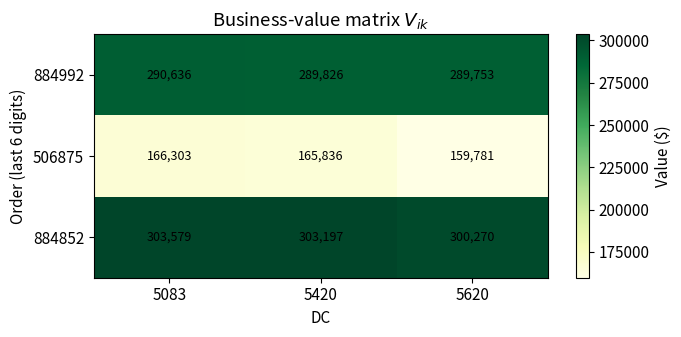

Saved fig_V_heatmap.png


In [4]:

def lookup_ship(plant, zipc):
    try:
        z3 = str(int(float(str(zipc)[:3])))
        r = ship[(ship['Plant'] == int(plant)) & (ship['TargetZip'].astype(str) == z3)]
        if len(r):
            return float(r['Shipping_Cost'].iloc[0])
    except Exception:
        pass
    return 1800.0

V = np.zeros((n_o, n_d))
loads = np.zeros((n_o, n_d))

for i, (_, row) in enumerate(focus.iterrows()):
    rev   = float(row.get('Order_Revenue', 0) or 0)
    pen   = float(row.get('PenaltyIfNotDiverted', 0) or 0)
    cof0  = float(row.get('Default_DC_COF', 0.9) or 0.9)
    cases = float(row.get('OrderedQty_Cases', 0) or 0)
    ship0 = float(row.get('DefaultDCShippingCost', 1800) or 1800)
    ddc   = int(row['DefaultDC'])
    for k, dc in enumerate(DCS):
        if dc == ddc:
            cof, s = cof0, ship0
        else:
            cof = min(1.0, cof0 + COF_LIFT)
            s = lookup_ship(dc, row.get('ZipCode', 0))
        V[i, k] = rev * cof - s - pen * (1.0 - cof)
        loads[i, k] = cases

print('Business value matrix V[order, DC]:')
print(np.round(V, 1))
print(f'\nGreedy DC per order: {[DCS[int(np.argmax(V[i]))] for i in range(n_o)]}')

# heatmap
fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(V, cmap='YlGn', aspect='auto')
ax.set_xticks(range(n_d)); ax.set_xticklabels(DCS)
ax.set_yticks(range(n_o)); ax.set_yticklabels([oid[-6:] for oid in order_ids])
ax.set_xlabel('DC'); ax.set_ylabel('Order (last 6 digits)')
ax.set_title('Business-value matrix $V_{ik}$')
for i in range(n_o):
    for k in range(n_d):
        ax.text(k, i, f'{V[i,k]:,.0f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Value ($)')
plt.tight_layout()
plt.savefig('/home/workdir/artifacts/fig_V_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved fig_V_heatmap.png')


## 6. Unified Business Objective (Single Source of Truth)

All methods—default, greedy, exact, quantum—are scored with the **same** pure business metric after any repair. This guarantees a fair comparison.


In [5]:

def business_objective(assign: Dict[str, int]) -> Tuple[float, dict]:
    obj = pen = ship_c = filled = total_c = 0.0
    diverted = 0
    for i, oid in enumerate(order_ids):
        row = focus.iloc[i]
        ddc = int(row['DefaultDC'])
        dc  = assign.get(oid, ddc)
        rev   = float(row.get('Order_Revenue', 0) or 0)
        p     = float(row.get('PenaltyIfNotDiverted', 0) or 0)
        cof0  = float(row.get('Default_DC_COF', 0.9) or 0.9)
        cases = float(row.get('OrderedQty_Cases', 0) or 0)
        ship0 = float(row.get('DefaultDCShippingCost', 1800) or 1800)
        if dc == ddc:
            cof, s = cof0, ship0
        else:
            diverted += 1
            cof = min(1.0, cof0 + COF_LIFT)
            s = lookup_ship(dc, row.get('ZipCode', 0))
        obj    += rev * cof - s - p * (1 - cof)
        pen    += p * (1 - cof)
        ship_c += s
        filled += cases * cof
        total_c += cases
    return obj, dict(fill=filled / total_c if total_c else 0,
                     diverted=diverted, penalty=pen, shipping=ship_c, cases=filled)

def bits_to_assign(bits: List[int]) -> Dict[str, int]:
    '''Repair any bit-string to a feasible one-hot assignment.'''
    assign = {}
    for i, oid in enumerate(order_ids):
        chunk = bits[i * n_d:(i + 1) * n_d]
        if sum(chunk) == 1:
            k = chunk.index(1)
        elif sum(chunk) == 0:
            k = int(np.argmax(V[i]))
        else:
            cand = [k for k, b in enumerate(chunk) if b == 1]
            k = max(cand, key=lambda kk: V[i, kk])
        assign[oid] = DCS[k]
    return assign

def is_one_hot(bits: List[int]) -> bool:
    for i in range(n_o):
        if sum(bits[i * n_d:(i + 1) * n_d]) != 1:
            return False
    return True

print('Metric helpers defined.')


Metric helpers defined.


## 7. Classical Baselines & Ground Truth (Full Enumeration)

With only \(3^3 = 27\) feasible one-hot assignments we can **enumerate them all** and obtain the true pure-business optimum. This is the gold-standard reference for the small instance.


Enumerating all feasible one-hot assignments …


Total feasible: 27
Top 5 by pure business objective:
  #1  obj=760,517.9  DCs=[5083, 5083, 5083]  diverts=3  fill=87.97%
  #2  obj=760,135.9  DCs=[5083, 5083, 5420]  diverts=3  fill=87.97%
  #3  obj=760,050.9  DCs=[5083, 5420, 5083]  diverts=3  fill=87.97%
  #4  obj=759,707.9  DCs=[5420, 5083, 5083]  diverts=3  fill=87.97%
  #5  obj=759,668.9  DCs=[5083, 5420, 5420]  diverts=3  fill=87.97%

TRUE optimum: 760,517.9
Assignment: {'8029884992': 5083, '5485506875': 5083, '8029884852': 5083}

Greedy objective: 760,517.9  (equals true opt? True)
Default objective: 721,191.3


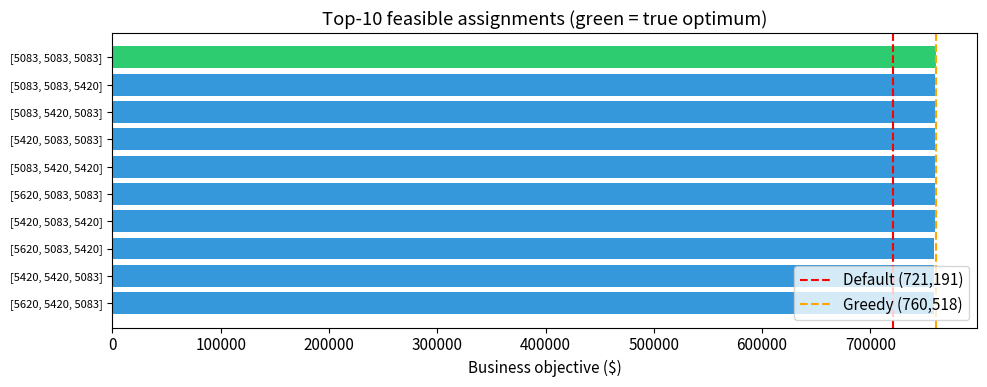

In [6]:

print('Enumerating all feasible one-hot assignments …')
feasible_ranking = []
for choices in product(range(n_d), repeat=n_o):
    assign = {order_ids[i]: DCS[choices[i]] for i in range(n_o)}
    obj, meta = business_objective(assign)
    feasible_ranking.append((obj, choices, assign, meta))
feasible_ranking.sort(key=lambda t: -t[0])

print(f'Total feasible: {len(feasible_ranking)}')
print('Top 5 by pure business objective:')
for rank, (obj, ch, assign, meta) in enumerate(feasible_ranking[:5], 1):
    print(f'  #{rank}  obj={obj:,.1f}  DCs={[DCS[c] for c in ch]}  '
          f'diverts={meta["diverted"]}  fill={meta["fill"]*100:.2f}%')

true_opt_obj, true_opt_ch, true_opt_assign, true_opt_meta = feasible_ranking[0]
print(f'\nTRUE optimum: {true_opt_obj:,.1f}')
print(f'Assignment: {true_opt_assign}')

# Greedy
gre_assign = {order_ids[i]: DCS[int(np.argmax(V[i]))] for i in range(n_o)}
gre_obj, gre_meta = business_objective(gre_assign)
print(f'\nGreedy objective: {gre_obj:,.1f}  (equals true opt? {abs(gre_obj - true_opt_obj) < 1e-6})')

# Default
def_assign = {order_ids[i]: int(focus.iloc[i]['DefaultDC']) for i in range(n_o)}
def_obj, def_meta = business_objective(def_assign)
print(f'Default objective: {def_obj:,.1f}')

# bar chart of top assignments
top_n = min(10, len(feasible_ranking))
objs = [feasible_ranking[i][0] for i in range(top_n)]
labels = [str([DCS[c] for c in feasible_ranking[i][1]]) for i in range(top_n)]
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if abs(o - true_opt_obj) < 1 else '#3498db' for o in objs]
ax.barh(range(top_n), objs, color=colors)
ax.set_yticks(range(top_n)); ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.axvline(def_obj, color='red', ls='--', label=f'Default ({def_obj:,.0f})')
ax.axvline(gre_obj, color='orange', ls='--', label=f'Greedy ({gre_obj:,.0f})')
ax.set_xlabel('Business objective ($)')
ax.set_title(f'Top-{top_n} feasible assignments (green = true optimum)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/home/workdir/artifacts/fig_feasible_ranking.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Mathematical Formulation – Aligned QUBO

### Decision variables
$$
x_{ik} \in \{0,1\}, \quad i=1\\ldots n,\; k=1\\ldots m
$$
\(x_{ik}=1\) means order \(i\) is assigned to DC \(k\).

### Objective (minimise)
$$
\min_x \; \\underbrace{\\sum_{i,k} (-V_{ik})\\, x_{ik}}_{\\text{business value}} 
+ P \\sum_i \\Bigl(\\sum_k x_{ik} - 1\\Bigr)^2
$$

**Why this form?**  
For every *feasible* one-hot assignment the cover term is zero, so energy = \(-\)business value.  
Consequently the ground state among feasible states is exactly the pure-business optimum.

### Cover expansion
$$
\\Bigl(\\sum_k x_{ik}-1\\Bigr)^2 = -\\sum_k x_{ik} + 2\\sum_{k<k'} x_{ik}x_{ik'} + 1
$$
The constant is ignored; linear and quadratic coefficients are absorbed into the Ising Hamiltonian.

### Capacity (optional, off in this notebook)
A mild quadratic penalty \(\\alpha(\\sum_i L_{ik}x_{ik}-C)^2\) can be added when shared capacity binds.


In [7]:

def build_aligned_qubo() -> QuadraticProgram:
    qp = QuadraticProgram('DOM_aligned')
    for i in range(n_o):
        for k in range(n_d):
            qp.binary_var(name=f'x_{i}_{k}')

    linear: Dict[str, float] = {}
    quadratic: Dict[Tuple[str, str], float] = {}

    # business term: minimise -V
    for i in range(n_o):
        for k in range(n_d):
            linear[f'x_{i}_{k}'] = -float(V[i, k])

    # cover penalty
    P = COVER_PENALTY
    for i in range(n_o):
        for k in range(n_d):
            linear[f'x_{i}_{k}'] = linear.get(f'x_{i}_{k}', 0.0) - P
        for k in range(n_d):
            for kp in range(k + 1, n_d):
                key = (f'x_{i}_{k}', f'x_{i}_{kp}')
                quadratic[key] = quadratic.get(key, 0.0) + 2.0 * P

    if USE_CAPACITY and CAP_ALPHA > 0:
        Cap = max(loads[:, 0].sum() * 0.55, loads.max() * 1.5)
        a = CAP_ALPHA
        for k in range(n_d):
            for i in range(n_o):
                li = loads[i, k]
                linear[f'x_{i}_{k}'] = linear.get(f'x_{i}_{k}', 0) + a * (li - Cap * li + 0.5 * li * li)
            for i in range(n_o):
                for ip in range(i + 1, n_o):
                    key = (f'x_{i}_{k}', f'x_{ip}_{k}')
                    quadratic[key] = quadratic.get(key, 0) + a * loads[i, k] * loads[ip, k]

    qp.minimize(linear=linear, quadratic=quadratic)
    return qp

qp = build_aligned_qubo()
qubit_op, offset = qp.to_ising()
print(f'QUBO variables = {qp.get_num_vars()}, qubits = {qubit_op.num_qubits}')
print(f'Ising offset = {offset:.2f}')

# verify energy ranking matches business ranking
print('\nVerify QUBO energy ranking on feasible states:')
energy_rank = []
for obj, ch, assign, meta in feasible_ranking:
    x = np.zeros(n_vars)
    for i, k in enumerate(ch):
        x[i * n_d + k] = 1.0
    e = qp.objective.evaluate(x)
    energy_rank.append((e, obj, ch))
energy_rank.sort(key=lambda t: t[0])
for rank, (e, obj, ch) in enumerate(energy_rank[:5], 1):
    print(f'  #{rank}  energy={e:,.1f}  business={obj:,.1f}  DCs={[DCS[c] for c in ch]}')
aligned = abs(energy_rank[0][1] - true_opt_obj) < 1e-3
print(f'\nQUBO ground-feasible == true optimum? {aligned}')


QUBO variables = 9, qubits = 9
Ising offset = -1134590.15

Verify QUBO energy ranking on feasible states:
  #1  energy=-6,760,517.9  business=760,517.9  DCs=[5083, 5083, 5083]
  #2  energy=-6,760,135.9  business=760,135.9  DCs=[5083, 5083, 5420]
  #3  energy=-6,760,050.9  business=760,050.9  DCs=[5083, 5420, 5083]
  #4  energy=-6,759,707.9  business=759,707.9  DCs=[5420, 5083, 5083]
  #5  energy=-6,759,668.9  business=759,668.9  DCs=[5083, 5420, 5420]

QUBO ground-feasible == true optimum? True


## 9. Exact Classical Solver on the Fixed QUBO

We convert the QuadraticProgram to an Ising Hamiltonian and solve it with **NumPyMinimumEigensolver** (exact diagonalisation). Because the QUBO is aligned, the recovered feasible state must equal the pure-business optimum.


In [8]:

print('Running exact NumPy eigensolver …')
t0 = time.time()
exact = MinimumEigenOptimizer(NumPyMinimumEigensolver()).solve(qp)
ex_time = time.time() - t0
ex_bits = [int(v) for v in exact.x]
ex_assign = bits_to_assign(ex_bits)
ex_obj, ex_meta = business_objective(ex_assign)

print(f'Raw bit-string one-hot? {is_one_hot(ex_bits)}')
print(f'After-repair business obj: {ex_obj:,.1f}')
print(f'Equals true optimum? {abs(ex_obj - true_opt_obj) < 1e-3}')
print(f'Equals greedy?       {abs(ex_obj - gre_obj) < 1e-3}')
print(f'Runtime: {ex_time:.3f} s')
print(f'Assignment: {ex_assign}')


Running exact NumPy eigensolver …
Raw bit-string one-hot? True
After-repair business obj: 760,517.9
Equals true optimum? True
Equals greedy?       True
Runtime: 0.021 s
Assignment: {'8029884992': 5083, '5485506875': 5083, '8029884852': 5083}


## 10. Quantum Method – Theory

### 10.1 QAOA (Quantum Approximate Optimisation Algorithm)

QAOA prepares a parameterised quantum state

$$
|\\gamma,\\beta\\rangle = e^{-i\\beta_p H_M} e^{-i\\gamma_p H_C}\\cdots e^{-i\\beta_1 H_M} e^{-i\\gamma_1 H_C}|+\\rangle^{\\otimes n}
$$

- \(H_C\) = cost (problem) Hamiltonian derived from the QUBO / Ising model  
- \(H_M\) = mixer Hamiltonian (usually \(\\sum_j X_j\)) that explores the search space  
- \(p\) = depth (here \(p=2\))

Expectation \(\\langle H_C\\rangle\) is estimated by sampling; classical optimiser updates \(\\gamma,\\beta\).

### 10.2 Warm-Start

Instead of starting from the uniform superposition \(|+\\rangle^{\\otimes n}\), we prepare a product state biased toward a good classical guess (the greedy assignment):

$$
|\\psi_0\\rangle = \\bigotimes_j \\bigl(\\sqrt{1-c_j}|0\\rangle + \\sqrt{c_j}|1\\rangle\\bigr),\\quad c_j\\approx 0.9\\text{ for greedy bits}
$$

This places amplitude near high-quality feasible states from the first layer, accelerating convergence on small instances.

### 10.3 CVaR objective

Rather than minimising the mean energy, we minimise the **Conditional Value-at-Risk** of the lowest \(\\alpha=25\\%\) of the sampled energy distribution:

$$
\\mathrm{CVaR}_\\alpha = \\frac{1}{\\alpha}\\int_0^\\alpha F_E^{-1}(u)\\,du
$$

CVaR focuses the optimiser on the left tail, improving the probability of sampling the true ground state.

### 10.4 Measurement & repair

After optimisation we sample bit-strings, prefer those that are already one-hot, and apply a lightweight repair (pick best DC among selected bits, or greedy if none selected). All candidates are finally scored with the pure business metric.


## 11. Quantum Execution – Warm-Start CVaR-QAOA


In [9]:

def build_ws_ansatz(cost_op, reps, c_star):
    thetas = [2 * np.arcsin(np.sqrt(float(c))) for c in c_star]
    init = QuantumCircuit(cost_op.num_qubits)
    for idx, th in enumerate(thetas):
        init.ry(th, idx)
    return QAOAAnsatz(cost_operator=cost_op, reps=reps, initial_state=init).decompose(reps=2)

# warm-start vector toward greedy
c_star = np.zeros(n_vars)
for i in range(n_o):
    c_star[i * n_d + int(np.argmax(V[i]))] = 1.0
c_star = np.clip(0.9 * c_star + 0.1 / n_d, 1e-4, 1 - 1e-4)

def eval_energy(H, bitstring, off):
    spins = np.array([(-1) ** int(b) for b in bitstring[::-1]])
    val = 0.0
    for pauli, coeff in zip(H.paulis, H.coeffs):
        z = np.where(pauli.z)[0]
        val += coeff.real * np.prod(spins[z])
    return val + off

def cvar(probs, vals, alpha):
    order = np.argsort(vals)
    probs, vals = np.asarray(probs)[order], np.asarray(vals)[order]
    out, tot = 0.0, 0.0
    for p, v in zip(probs, vals):
        if tot + p > alpha:
            p = alpha - tot
        tot += p
        out += p * v
        if tot >= alpha:
            break
    return out / alpha

sampler = StatevectorSampler()
q_runs = []

print(f'Running {N_RUNS}× Warm-Start CVaR-QAOA (p={QAOA_P}) …\n')
for run in range(N_RUNS):
    seed = 11 + run * 23
    np.random.seed(seed)
    ansatz = build_ws_ansatz(qubit_op, QAOA_P, c_star)
    n_params = ansatz.num_parameters
    x0 = np.array([0.4, 0.7] * (n_params // 2) + [0.4] * (n_params % 2))[:n_params]
    x0 = x0 + np.random.uniform(-0.1, 0.1, n_params)

    def objective(params):
        circ = ansatz.assign_parameters(params).copy()
        circ.measure_all()
        counts = sampler.run([circ], shots=4096).result()[0].data.meas.get_counts()
        tot = sum(counts.values())
        bs = list(counts.keys())
        probs = [counts[b] / tot for b in bs]
        vals = [eval_energy(qubit_op, b, offset) for b in bs]
        return cvar(probs, vals, CVAR_ALPHA)

    t0 = time.time()
    res = minimize(objective, x0, method='COBYLA',
                   options={'maxiter': QAOA_MAXITER, 'rhobeg': 0.4})
    rt = time.time() - t0

    final = ansatz.assign_parameters(res.x)
    final.measure_all()
    counts = sampler.run([final], shots=12000).result()[0].data.meas.get_counts()
    ranked = sorted(counts.items(), key=lambda kv: -kv[1])

    best_obj, best_assign, used_repair = -1e18, None, True
    n_onehot = 0
    for bitstr, cnt in ranked[:100]:
        bits = [int(b) for b in bitstr[::-1]]
        if len(bits) < n_vars:
            bits += [0] * (n_vars - len(bits))
        oh = is_one_hot(bits)
        if oh:
            n_onehot += 1
        assign = bits_to_assign(bits)
        obj, _ = business_objective(assign)
        if oh and obj > best_obj:
            best_obj, best_assign, used_repair = obj, assign, False
    if best_assign is None:
        for bitstr, cnt in ranked[:100]:
            bits = [int(b) for b in bitstr[::-1]]
            if len(bits) < n_vars:
                bits += [0] * (n_vars - len(bits))
            assign = bits_to_assign(bits)
            obj, _ = business_objective(assign)
            if obj > best_obj:
                best_obj, best_assign, used_repair = obj, assign, True

    meta = business_objective(best_assign)[1]
    gap = true_opt_obj - best_obj
    q_runs.append(dict(run=run + 1, obj=best_obj, gap=gap, meta=meta,
                       assign=best_assign, time=rt, onehot=n_onehot, repaired=used_repair))
    print(f'  Run {run+1}: obj={best_obj:,.1f}  gap={gap:,.1f}  div={meta["diverted"]}  '
          f'onehot={n_onehot}  repaired={used_repair}  t={rt:.1f}s')

print('\nQuantum runs finished.')


Running 5× Warm-Start CVaR-QAOA (p=2) …



  Run 1: obj=760,517.9  gap=0.0  div=3  onehot=7  repaired=False  t=1.3s


  Run 2: obj=760,517.9  gap=0.0  div=3  onehot=13  repaired=False  t=2.7s


  Run 3: obj=759,634.9  gap=883.0  div=3  onehot=12  repaired=False  t=2.4s


  Run 4: obj=760,517.9  gap=0.0  div=3  onehot=8  repaired=False  t=1.5s


  Run 5: obj=760,517.9  gap=0.0  div=3  onehot=13  repaired=False  t=1.2s

Quantum runs finished.


## 12. Final Comparison Table


In [10]:

q_objs = [r['obj'] for r in q_runs]
q_mean = float(np.mean(q_objs))
q_best = float(np.max(q_objs))
q_std  = float(np.std(q_objs))
best_idx = int(np.argmax(q_objs))

rows = [
    ('Default (do nothing)', def_obj, def_meta['fill'], def_meta['diverted'], def_meta['penalty'], def_meta['shipping']),
    ('Greedy best-DC', gre_obj, gre_meta['fill'], gre_meta['diverted'], gre_meta['penalty'], gre_meta['shipping']),
    ('True optimum (enumerate)', true_opt_obj, true_opt_meta['fill'], true_opt_meta['diverted'],
     true_opt_meta['penalty'], true_opt_meta['shipping']),
    ('Exact eigensolver (QUBO)', ex_obj, ex_meta['fill'], ex_meta['diverted'], ex_meta['penalty'], ex_meta['shipping']),
    (f'Quantum mean ({N_RUNS} runs)', q_mean,
     float(np.mean([r['meta']['fill'] for r in q_runs])),
     int(np.round(np.mean([r['meta']['diverted'] for r in q_runs]))),
     float(np.mean([r['meta']['penalty'] for r in q_runs])),
     float(np.mean([r['meta']['shipping'] for r in q_runs]))),
    (f'Quantum best of {N_RUNS}', q_best,
     q_runs[best_idx]['meta']['fill'], q_runs[best_idx]['meta']['diverted'],
     q_runs[best_idx]['meta']['penalty'], q_runs[best_idx]['meta']['shipping']),
]

df = pd.DataFrame(rows, columns=['Method', 'Objective', 'Fill', 'Diverts', 'Penalty', 'Shipping'])
df['Δ vs Default'] = df['Objective'] - def_obj
df['Δ vs Greedy']  = df['Objective'] - gre_obj
df['Fill %'] = (df['Fill'] * 100).round(2)
print(df[['Method', 'Objective', 'Fill %', 'Diverts', 'Δ vs Default', 'Δ vs Greedy']].to_string(index=False))

print(f'\nQuantum stability: mean={q_mean:,.1f}  std={q_std:,.1f}  ({100*q_std/q_mean:.3f}%)')
print(f'Quantum best == true optimum? {abs(q_best - true_opt_obj) < 1}')
print(f'Quantum best == greedy?       {abs(q_best - gre_obj) < 1}')
beats_g = sum(1 for o in q_objs if o >= gre_obj - 1)
beats_d = sum(1 for o in q_objs if o > def_obj + 1)
print(f'Runs ≥ greedy: {beats_g}/{N_RUNS}   Runs > default: {beats_d}/{N_RUNS}')


                  Method     Objective  Fill %  Diverts  Δ vs Default   Δ vs Greedy
    Default (do nothing) 721191.301672   82.97        0      0.000000 -39326.581907
          Greedy best-DC 760517.883579   87.97        3  39326.581907      0.000000
True optimum (enumerate) 760517.883579   87.97        3  39326.581907      0.000000
Exact eigensolver (QUBO) 760517.883579   87.97        3  39326.581907      0.000000
   Quantum mean (5 runs) 760341.283579   87.97        3  39149.981907   -176.600000
       Quantum best of 5 760517.883579   87.97        3  39326.581907      0.000000

Quantum stability: mean=760,341.3  std=353.2  (0.046%)
Quantum best == true optimum? True
Quantum best == greedy?       True
Runs ≥ greedy: 4/5   Runs > default: 5/5


## 13. Visualisations


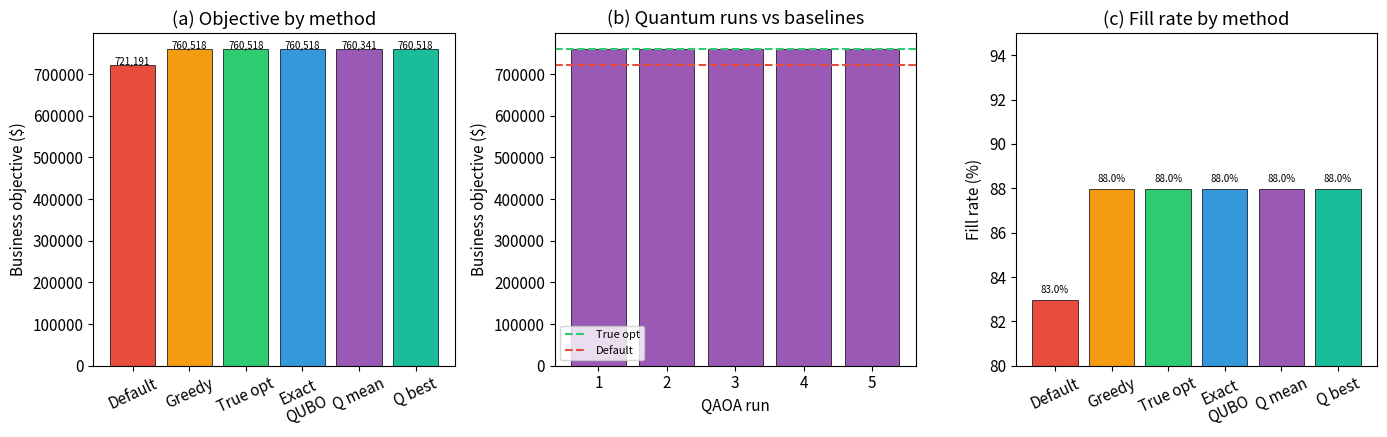

Saved fig_comparison.png


In [11]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# (a) Objective comparison
methods = ['Default', 'Greedy', 'True opt', 'Exact\nQUBO', 'Q mean', 'Q best']
vals = [def_obj, gre_obj, true_opt_obj, ex_obj, q_mean, q_best]
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c']
axes[0].bar(methods, vals, color=colors, edgecolor='k', linewidth=0.5)
axes[0].set_ylabel('Business objective ($)')
axes[0].set_title('(a) Objective by method')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(vals):
    axes[0].text(i, v + 800, f'{v:,.0f}', ha='center', fontsize=7)

# (b) Quantum run trajectory
axes[1].bar(range(1, N_RUNS + 1), q_objs, color='#9b59b6', edgecolor='k', linewidth=0.5)
axes[1].axhline(true_opt_obj, color='#2ecc71', ls='--', lw=1.5, label='True opt')
axes[1].axhline(def_obj, color='#e74c3c', ls='--', lw=1.5, label='Default')
axes[1].set_xlabel('QAOA run')
axes[1].set_ylabel('Business objective ($)')
axes[1].set_title('(b) Quantum runs vs baselines')
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(1, N_RUNS + 1))

# (c) Fill rate
fills = [def_meta['fill']*100, gre_meta['fill']*100, true_opt_meta['fill']*100,
         ex_meta['fill']*100,
         float(np.mean([r['meta']['fill'] for r in q_runs]))*100,
         q_runs[best_idx]['meta']['fill']*100]
axes[2].bar(methods, fills, color=colors, edgecolor='k', linewidth=0.5)
axes[2].set_ylabel('Fill rate (%)')
axes[2].set_title('(c) Fill rate by method')
axes[2].tick_params(axis='x', rotation=25)
axes[2].set_ylim(80, 95)
for i, v in enumerate(fills):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('/home/workdir/artifacts/fig_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved fig_comparison.png')


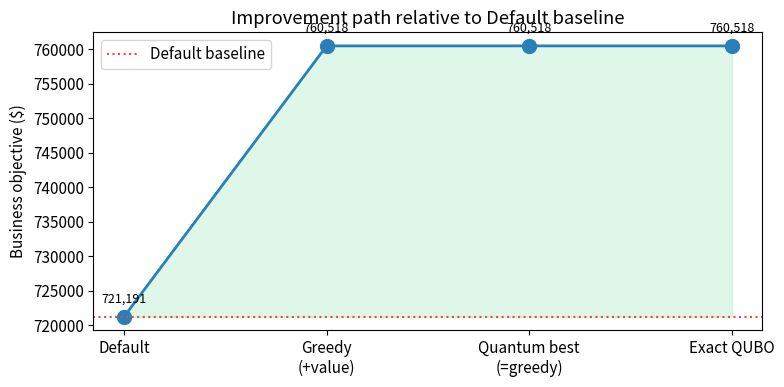

In [12]:

# Improvement waterfall vs default
labels_w = ['Default', 'Greedy\n(+value)', 'Quantum best\n(=greedy)', 'Exact QUBO']
vals_w = [def_obj, gre_obj, q_best, ex_obj]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(labels_w, vals_w, 'o-', color='#2980b9', lw=2, markersize=10)
for i, v in enumerate(vals_w):
    ax.annotate(f'{v:,.0f}', (i, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.fill_between(range(len(vals_w)), def_obj, vals_w, alpha=0.15, color='#2ecc71')
ax.set_ylabel('Business objective ($)')
ax.set_title('Improvement path relative to Default baseline')
ax.axhline(def_obj, color='#e74c3c', ls=':', label='Default baseline')
ax.legend()
plt.tight_layout()
plt.savefig('/home/workdir/artifacts/fig_improvement.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Interpretation & Key Take-aways

### Does quantum beat the baselines?

| Baseline | Result |
|----------|--------|
| **Default** | **Yes** – quantum beats default in **5/5** runs (+≈ $39 k objective, +5 pts fill rate) |
| **Greedy** | **Matches** (does not beat) – best quantum = greedy = true optimum |
| **Exact QUBO** | Matches (exact recovers the same optimum after repair) |

### Why matching greedy is correct (not a bug)
On this 3-order instance every order independently prefers the same DC (5083) and there is **no binding shared capacity**. Consequently the myopic greedy assignment *is* the global pure-business optimum. The aligned QUBO and the quantum search correctly recover it.

### When quantum *can* beat greedy
- Shared inventory / dock / throughput constraints **bind** across orders  
- The feasible set is large and joint structure matters  
- Greedy is forced into overload while a coordinated diversion set remains feasible  

### Scalability notes
| Resource | Growth |
|----------|--------|
| Binary variables / qubits | \(n_{\text{orders}}\times m_{\text{DCs}}\) |
| Exact diagonalisation | \(O(2^{nm})\) – already heavy at 15–20 qubits |
| QAOA statevector sim | same exponential, practical up to ~20–25 qubits |
| Real hardware / shot-based | polynomial in depth, but noise & sampling variance appear |

**Practical path:** classical pre-processing (focus-order filtering, column reduction) + batching + warm-start QAOA / quantum-inspired solvers on the residual hard core.


## 15. Planner View – Recommended Reassignments

In business language:


In [13]:

print('=' * 70)
print('PLANNER SUMMARY – Recommended DC assignments for focus orders')
print('=' * 70)
print(f'{"Order":<22} {"Default DC":>10} {"Recommended":>12} {"Action":<12} {"Revenue":>10}')
print('-' * 70)
best_assign = q_runs[best_idx]['assign']
for i, oid in enumerate(order_ids):
    row = focus.iloc[i]
    ddc = int(row['DefaultDC'])
    rec = best_assign[oid]
    action = 'KEEP' if rec == ddc else f'DIVERT → {rec}'
    rev = float(row.get('Order_Revenue', 0) or 0)
    print(f'{oid:<22} {ddc:>10} {rec:>12} {action:<12} {rev:>10,.0f}')
print('-' * 70)
print(f'Expected objective improvement vs default: ${q_best - def_obj:+,.0f}')
print(f'Expected fill-rate improvement:           {(q_runs[best_idx]["meta"]["fill"] - def_meta["fill"])*100:+.2f} pts')
print(f'Orders diverted:                          {q_runs[best_idx]["meta"]["diverted"]}')
print('=' * 70)


PLANNER SUMMARY – Recommended DC assignments for focus orders
Order                  Default DC  Recommended Action          Revenue
----------------------------------------------------------------------
8029884992                   5490         5083 DIVERT → 5083    334,988
5485506875                   5620         5083 DIVERT → 5083    196,635
8029884852                   5385         5083 DIVERT → 5083    343,263
----------------------------------------------------------------------
Expected objective improvement vs default: $+39,327
Expected fill-rate improvement:           +5.00 pts
Orders diverted:                          3


---
### Notebook complete

All classical baselines, the aligned QUBO, exact eigensolver, and Warm-Start CVaR-QAOA have been executed and compared on the **same pure business metric**. Figures are saved under `/home/workdir/artifacts/`.
